In [1]:
# the libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'daiys'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds


def build_weights(data, datadata, minvalue = -999, latlim = 90.):
    weights = datadata.isel(time = 0) > minvalue
    weights = weights *np.cos( np.deg2rad(data.lat))
    weights = weights*(abs(data.lat)<latlim)
    return weights

def weighted(data, datadata, weights):
    datadata_weighted = datadata.weighted(weights)
    weighted_mean = datadata_weighted.mean(('lat', 'lon'))
    return weighted_mean

In [3]:
def spaghetti(dataset, index_name, outputname, title = ''):
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(12, 6))

    # Use Seaborn's lineplot to create the spaghetti plot
    sns.lineplot(data = dataset, x = dataset.time.dt.dayofyear, y = index_name,
                 hue = dataset.time.dt.year,
                 palette=['lightgrey' for y in np.unique(dataset.time.dt.year)],
                 style=None,
                 ax=ax,
                 legend=False)

    # Manually select years to highlight with different colors
    vstrong_ninos = [1982, 1997, 2015]
    styles = []
    strong_ninos = [1965, 1972,1987, 1991]

    #plot 2023
    sns.lineplot(data=dataset.where(dataset.time.dt.year == 2023), x=dataset.time.dt.dayofyear, y=index_name, color='blue', ax=ax, label=str(2023))

    sns.lineplot(data=dataset.where(dataset.time.dt.year == 2015), x=dataset.time.dt.dayofyear, y=index_name, color='red', marker = 'x', ax=ax, label = '2015')
    sns.lineplot(data=dataset.where(dataset.time.dt.year == 1997), x=dataset.time.dt.dayofyear, y=index_name, color='red', marker = 'o', ax=ax, label = '1997')
    sns.lineplot(data=dataset.where(dataset.time.dt.year == 1982), x=dataset.time.dt.dayofyear, y=index_name, color='red', marker = '.', ax=ax, label = '1982')

    for year in strong_ninos:
        sns.lineplot(data=dataset.where(dataset.time.dt.year == year), x=dataset.time.dt.dayofyear, y=index_name, color='orange', ax=ax, label=str(year))

    # Customize the plot
    ax.set_xlabel('Month')
    ax.set_ylabel(index_name)
    ax.set_title(title)
    ax.legend(loc = 'lower right')

    # Show the plot
    #plt.savefig('/data/jmex/output/figures/same_start/{}.png'.format(outputname))


In [38]:
fp = '/data/jmex/NCEP/inolr_110-150E_20--20N_n.nc'
olr = decode_time(fp)
anom = olr.groupby('time.month')-olr.groupby('time.month').mean()
olr = anom

Text(0, 0.5, 'OLR Anomaly [K]')

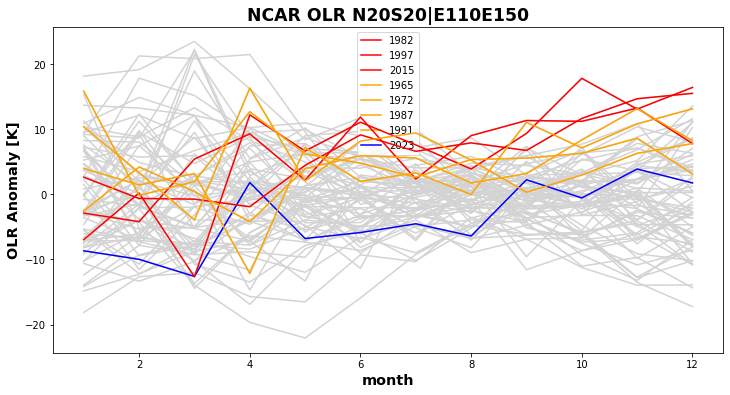

In [41]:
fig, ax = plt.subplots(figsize = (12,6))
sns.lineplot(data = olr, x = olr.time.dt.month, y = olr.ulwrf,
            palette = ['lightgrey' for y in np.unique(olr.time.dt.year)],
            hue = olr.time.dt.year,
            ax = ax, legend = False)

vstrong_ninos = [1982, 1997, 2015]
for y in vstrong_ninos:
    sns.lineplot(data = olr.where(olr.time.dt.year == y), x = olr.time.dt.month, y = 'ulwrf',
                ax = ax, label = y,
                color = 'r',
                zorder = 10)
    
strong_ninos = [1965, 1972,1987, 1991]
for y in strong_ninos:
    sns.lineplot(data = olr.where(olr.time.dt.year == y), x = olr.time.dt.month, y = 'ulwrf',
                ax = ax, label = y,
                color = 'orange',
                zorder = 10)

        
    
sns.lineplot(data = olr.sel(time = '2023'), x = olr.sel(time = '2023').time.dt.month, y = 'ulwrf',
            ax = ax, label = '2023', color = 'b')

ax.set_title('NCAR OLR N20S20|E110E150')
ax.set_ylabel('OLR Anomaly [K]')

In [33]:
fp = '/data/jmex/NCEP/inolr_130-150E_20--20N_n.nc'
olr = decode_time(fp).sel(time = slice('1958', '2023'))


In [35]:
anom = olr.groupby('time.month')-olr.groupby('time.month').mean()
anom
olr = anom

Text(0, 0.5, 'OLR Anomaly [K]')

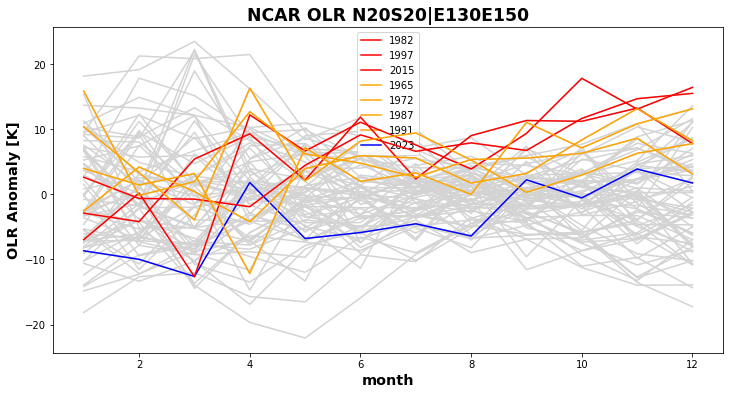

In [40]:
fig, ax = plt.subplots(figsize = (12,6))
sns.lineplot(data = olr, x = olr.time.dt.month, y = olr.ulwrf,
            palette = ['lightgrey' for y in np.unique(olr.time.dt.year)],
            hue = olr.time.dt.year,
            ax = ax, legend = False)

vstrong_ninos = [1982, 1997, 2015]
for y in vstrong_ninos:
    sns.lineplot(data = olr.where(olr.time.dt.year == y), x = olr.time.dt.month, y = 'ulwrf',
                ax = ax, label = y,
                color = 'r',
                zorder = 10)
    
strong_ninos = [1965, 1972,1987, 1991]
for y in strong_ninos:
    sns.lineplot(data = olr.where(olr.time.dt.year == y), x = olr.time.dt.month, y = 'ulwrf',
                ax = ax, label = y,
                color = 'orange',
                zorder = 10)

        
    
sns.lineplot(data = olr.sel(time = '2023'), x = olr.sel(time = '2023').time.dt.month, y = 'ulwrf',
            ax = ax, label = '2023', color = 'b')

ax.set_title('NCAR OLR N20S20|E130E150')
ax.set_ylabel('OLR Anomaly [K]')

In [7]:
olr

<xarray.Dataset>
Dimensions:  (time: 924)
Coordinates:
  * time     (time) datetime64[ns] 1948-02-01 1948-03-01 ... 2025-01-01
Data variables:
    ulwrf    (time) float32 231.7 227.0 237.9 241.6 237.3 ... nan nan nan nan
Attributes: (12/15)
    title:                   spatial statistic of monthly mean ulwrf.ntat fro...
    description:             Data is from NMC initialized reanalysis\n(4x/day...
    minimal_valid_fraction:   30.00
    file:                    NCEPNCAR40/ulwrf.ntat.mon.mean.nc
    platform:                Model
    nco:                     20121012
    ...                      ...
    scripturl01:             http://climexp.knmi.nl/get_index.cgi?email=someo...
    ave_region:              lon=  109.688  150.938, lat=  -20.952   20.952
    comment:                 
    scripturl02:             http://climexp.knmi.nl/dat2nc.cgi?id=someone@som...
    history:                  2024-05-16  7:19:39 ./bin/dat2nc data/inolr_110...
    Conventions:             CF-1.0

# Precip

In [4]:
#read in sst
fp = '/data/jmex/ERA5/daily/era5_tp_daily_130-150E_-20-20N.nc'

ds = xr.open_dataset(fp)
tp = ds.weighted(np.cos(np.deg2rad(ds.lat))).mean(['lat','lon'])

In [5]:
tp = tp.rolling(time=30).mean()

In [8]:
r= tp#.groupby(tp.time.dt.year)#-tp.groupby(tp.time.dt.year).first()

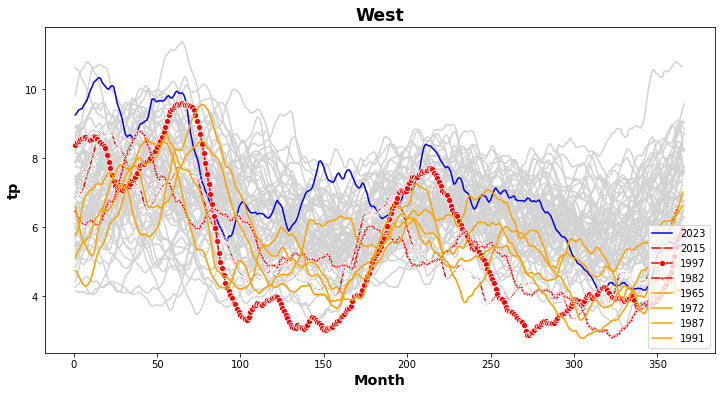

In [9]:
spaghetti(r, 'tp', 'precip_east', 'West')

# Global

In [4]:
#read in sst
fp = '/data/jmex/ERA5/daily/era5_t2m_dailymean.nc'

ds = xr.open_dataset(fp).isel(lat = 0, lon = 0)

In [5]:
#compute mean
daily_mean = ds.groupby(ds.time.dt.dayofyear).mean('time')
#compute anomaly 
anomalies = ds.groupby(ds.time.dt.dayofyear)-daily_mean


#result
result = anomalies.groupby(anomalies.time.dt.year)-anomalies.groupby(anomalies.time.dt.year).first()
r = result.copy()

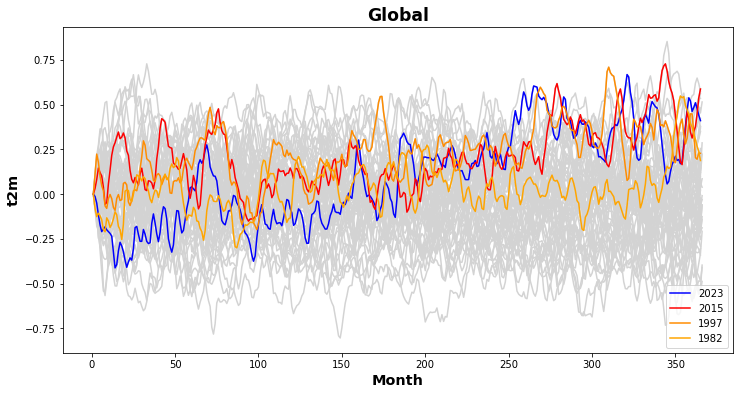

In [6]:
spaghetti(r, 't2m', 't2m_global', 'Global')

# S20N20

In [7]:
#read in sst
fp = '/data/jmex/ERA5/daily/era5_t2m_dailymean_S20N20.nc'

ds = xr.open_dataset(fp).isel(lat = 0, lon = 0)

In [8]:
#compute mean
daily_mean = ds.groupby(ds.time.dt.dayofyear).mean('time')
#compute anomaly 
anomalies = ds.groupby(ds.time.dt.dayofyear)-daily_mean


#result
result = anomalies.groupby(anomalies.time.dt.year)-anomalies.groupby(anomalies.time.dt.year).first()
r = result.copy()

NameError: name 'strong_ninos' is not defined

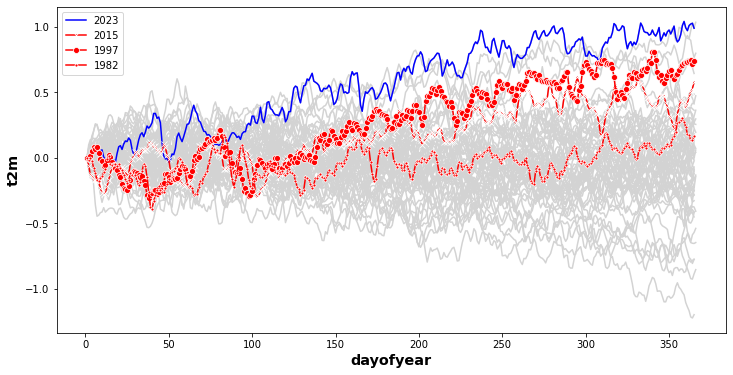

In [10]:
spaghetti(r, 't2m', 't2m_S20N20', 'S20N20')

# N20N60

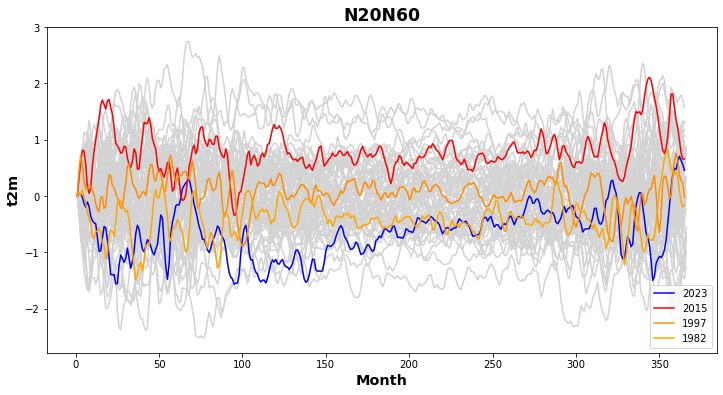

In [10]:
#read in sst
fp = '/data/jmex/ERA5/daily/era5_t2m_dailymean_N20N60.nc'

ds = xr.open_dataset(fp).isel(lat = 0, lon = 0)

#compute mean
daily_mean = ds.groupby(ds.time.dt.dayofyear).mean('time')
#compute anomaly 
anomalies = ds.groupby(ds.time.dt.dayofyear)-daily_mean


#result
result = anomalies.groupby(anomalies.time.dt.year)-anomalies.groupby(anomalies.time.dt.year).first()
r = result.copy()
spaghetti(r, 't2m', 't2m_N20N60', 'N20N60')

# S60S20

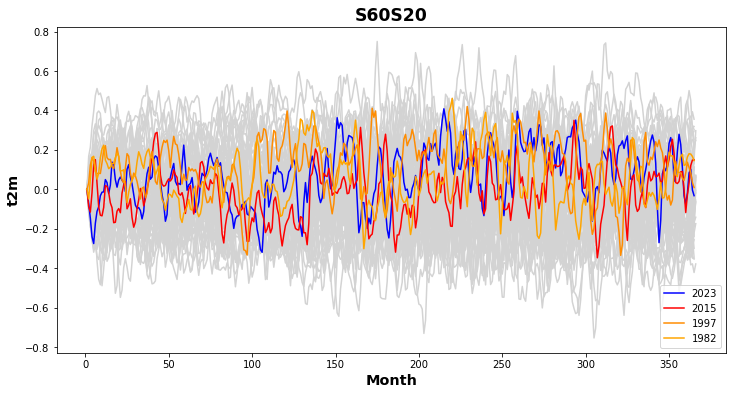

In [15]:
#read in sst
fp = '/data/jmex/ERA5/daily/era5_t2m_dailymean_S60S20.nc'

ds = xr.open_dataset(fp).isel(lat = 0, lon = 0)

#compute mean
daily_mean = ds.groupby(ds.time.dt.dayofyear).mean('time')
#compute anomaly 
anomalies = ds.groupby(ds.time.dt.dayofyear)-daily_mean


#result
result = anomalies.groupby(anomalies.time.dt.year)-anomalies.groupby(anomalies.time.dt.year).first()
r = result.copy()
spaghetti(r, 't2m', 't2m_S60s20', 'S60S20')